<a href="https://colab.research.google.com/github/roshelinanusiya/INTERNSHIP/blob/main/salary_prediction_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Data Preprocessing**



In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load data
df = pd.read_csv('employee_salary_dataset.csv')

# Encode categorical variables
le = LabelEncoder()
for col in ['Gender', 'Education', 'Department']:
    df[col] = le.fit_transform(df[col])

# Create Salary Category for Classification (Logistic Regression)
# High: > 100k, Medium: 60k-100k, Low: < 60k
def categorize_salary(val):
    if val > 100000: return 2 # High
    if val > 60000: return 1  # Medium
    return 0                  # Low

df['Salary_Class'] = df['Salary'].apply(categorize_salary)

# Features
X = df[['Age', 'Gender', 'Education', 'Department', 'Experience', 'Working_Hours', 'Performance_Score', 'Projects_Completed']]

# Splits
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, df['Salary'], test_size=0.2, random_state=42)
_, _, y_train_clf, y_test_clf = train_test_split(X, df['Salary_Class'], test_size=0.2, random_state=42)

# Scaling (Required for Linear/Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing Complete.")

Preprocessing Complete.


**2. Algorithm A: Linear Regression**

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize and train
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_reg)

# Predict and Evaluate
lr_preds = lr_model.predict(X_test_scaled)
print("--- Linear Regression Results ---")
print(f"R2 Score (Accuracy): {r2_score(y_test_reg, lr_preds):.4f}")
print(f"Mean Absolute Error: ${mean_absolute_error(y_test_reg, lr_preds):,.2f}")


--- Linear Regression Results ---
R2 Score (Accuracy): 1.0000
Mean Absolute Error: $0.00


**3. Algorithm B: Logistic Regression**

--- Logistic Regression Results ---
Classification Accuracy: 100.00%


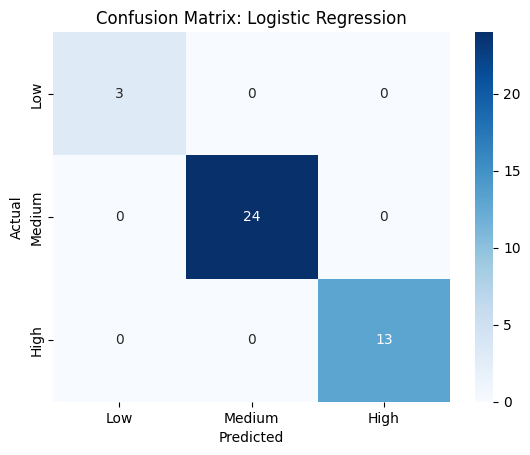

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize and train
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train_clf)

# Predict and Evaluate
log_preds = log_model.predict(X_test_scaled)
print("--- Logistic Regression Results ---")
print(f"Classification Accuracy: {accuracy_score(y_test_clf, log_preds):.2%}")

# Confusion Matrix Visualization
cm = confusion_matrix(y_test_clf, log_preds)
sns.heatmap(cm, annot=True, xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'], cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

**4. Algorithm C: Random Forest**

--- Random Forest Results ---
R2 Score: 0.9727
Mean Absolute Error: $3,341.00


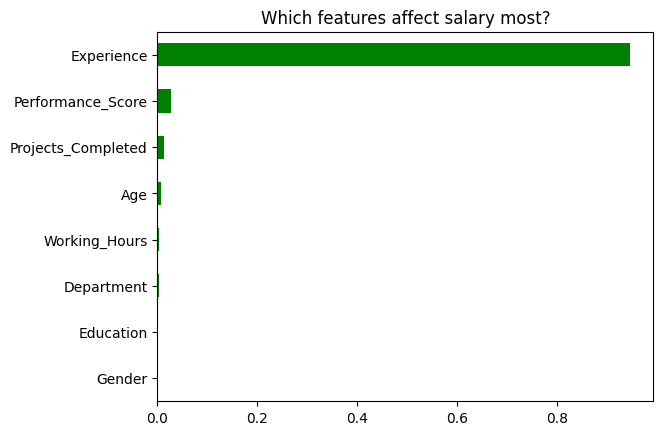

In [25]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train_reg) # Random forest doesn't strictly require scaling

# Predict and Evaluate
rf_preds = rf_model.predict(X_test)
print("--- Random Forest Results ---")
print(f"R2 Score: {r2_score(y_test_reg, rf_preds):.4f}")
print(f"Mean Absolute Error: ${mean_absolute_error(y_test_reg, rf_preds):,.2f}")

# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', color='green')
plt.title('Which features affect salary most?')
plt.show()

**5. Visualization D:Create graphs for**

**1. Salary Distribution**

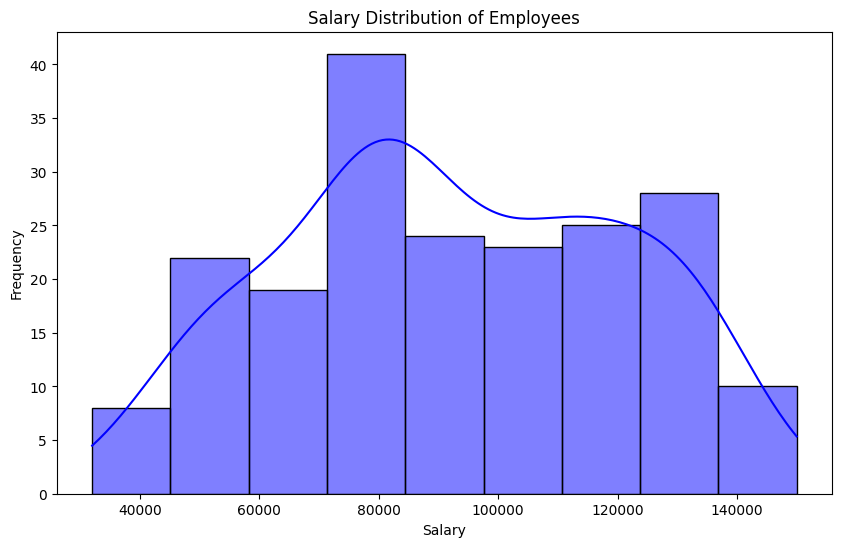

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(df['Salary'], kde=True, color='blue')
plt.title('Salary Distribution of Employees')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

**2. Correlation Heatmap**

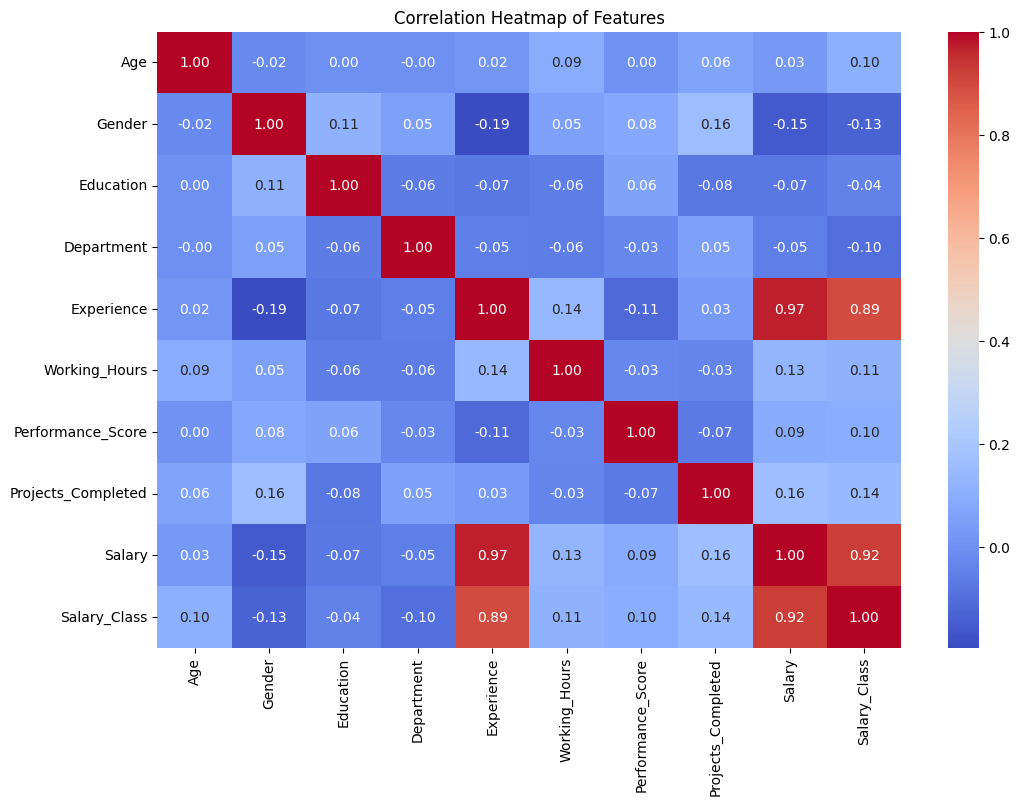

In [27]:
plt.figure(figsize=(12, 8))
# We drop Employee_ID as it is just a serial number and not a predictor
correlation_matrix = df.drop(columns=['Employee_ID']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Features')
plt.show()

**3. Experience vs. Salary**

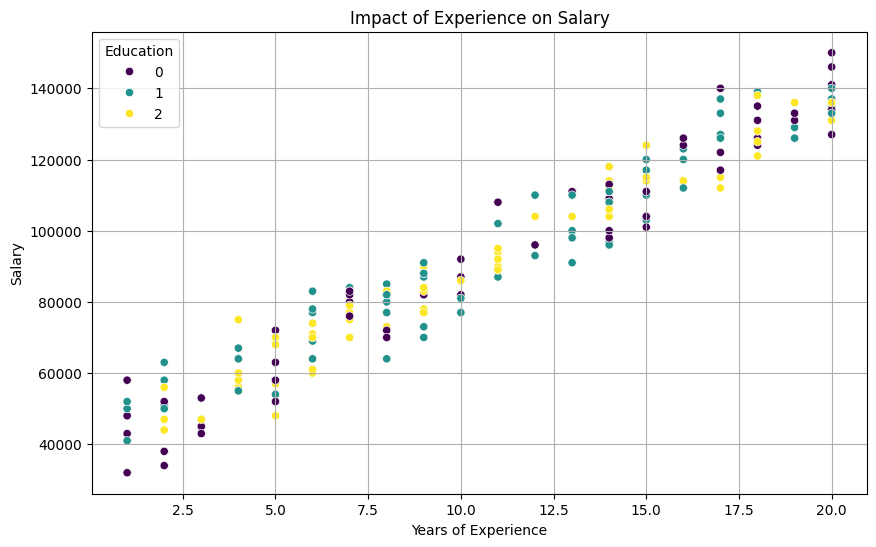

In [28]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Experience', y='Salary', data=df, hue='Education', palette='viridis')
plt.title('Impact of Experience on Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.grid(True)
plt.show()

**4. Department-wise Comparison**

/tmp/ipykernel_12511/888750552.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Department', y='Salary', data=df, estimator=np.mean, palette='magma')


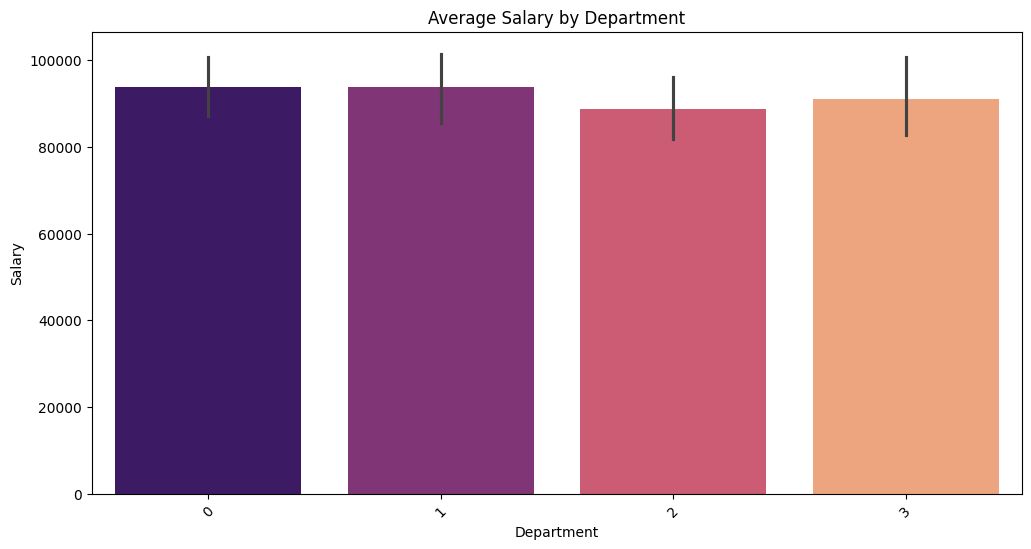

In [29]:
plt.figure(figsize=(12, 6))
# Using the original categorical names for the X-axis
sns.barplot(x='Department', y='Salary', data=df, estimator=np.mean, palette='magma')
plt.title('Average Salary by Department')
plt.xticks(rotation=45)
plt.show()

**5. Feature Importance Graph**

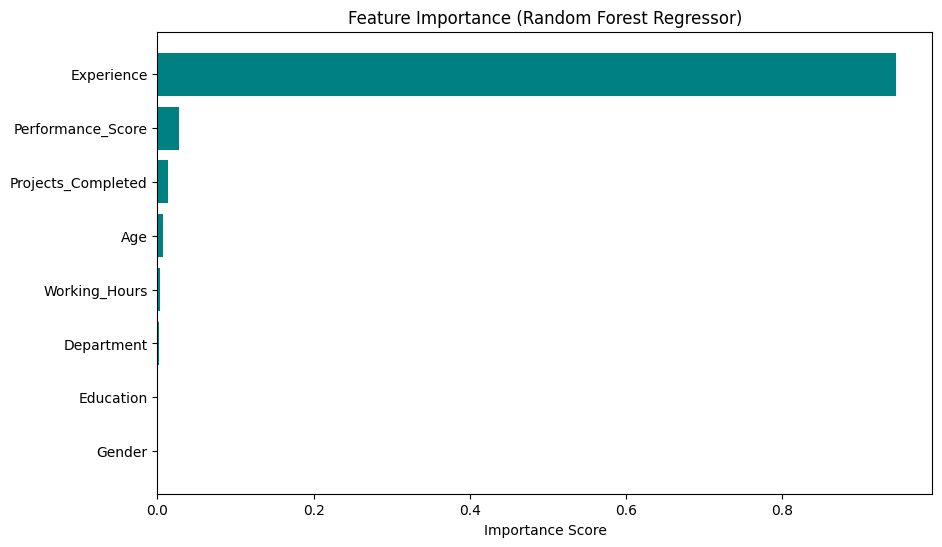

In [30]:
# Assuming 'rf_model' was trained in the previous step
importances = rf_model.feature_importances_
feature_names = ['Age', 'Gender', 'Education', 'Department', 'Experience', 'Working_Hours', 'Performance_Score', 'Projects_Completed']
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='teal')
plt.title('Feature Importance (Random Forest Regressor)')
plt.xlabel('Importance Score')
plt.show()

 5. Model Evaluation:Compare models using

**1. Regression Metrics**

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("--- Regression Model Comparison ---")
print(f"Linear Regression R2: {r2_score(y_test_reg, lr_preds):.4f}")
print(f"Linear Regression MAE: {mean_absolute_error(y_test_reg, lr_preds):.2f}")
print(f"Random Forest R2: {r2_score(y_test_reg, rf_preds):.4f}")
print(f"Random Forest MAE: {mean_absolute_error(y_test_reg, rf_preds):.2f}")

--- Regression Model Comparison ---
Linear Regression R2: 1.0000
Linear Regression MAE: 0.00
Random Forest R2: 0.9727
Random Forest MAE: 3341.00


**2. Classification Metrics**

In [36]:
from sklearn.metrics import accuracy_score
print("--- Classification Model Comparison ---")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test_clf, log_preds):.2%}")


--- Classification Model Comparison ---
Logistic Regression Accuracy: 100.00%


**3. Confusion Matrix**

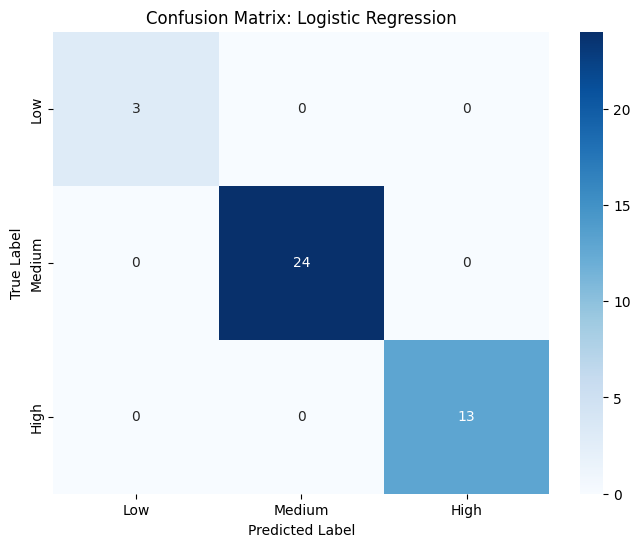

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test_clf, log_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

2026-05-13 17:42:37.053 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-13 17:42:37.058 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-05-13 17:42:37.059 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-05-13 17:42:37.060 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-13 17:42:37.255 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-13 17:42:37.366 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-13 17:42:37.367 Thread 'MainThread': mi

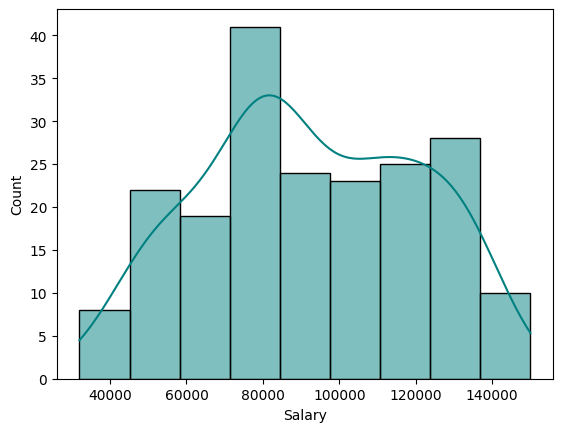

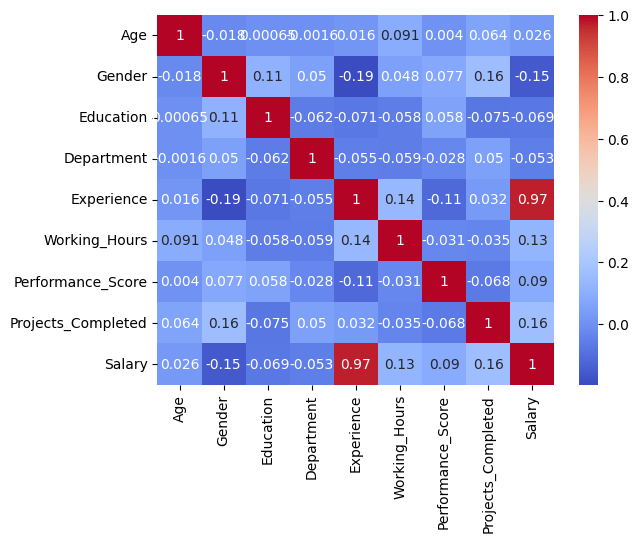

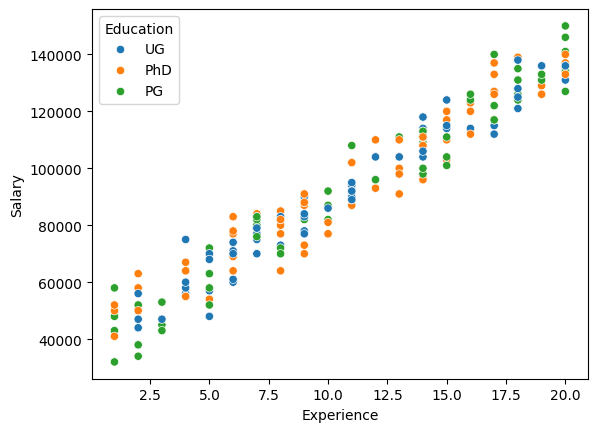

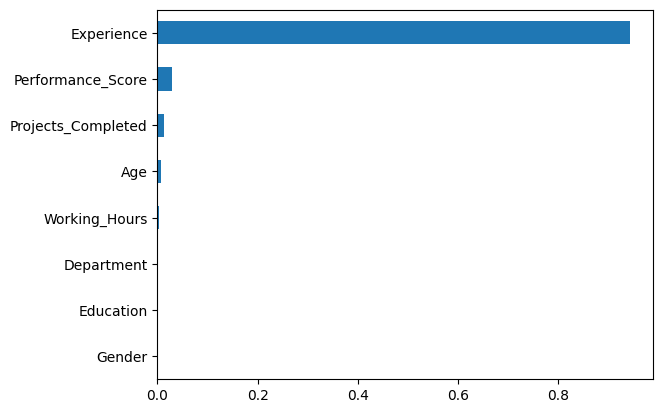

In [43]:
import streamlit as st
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score
st.set_page_config(page_title="Salary Prediction System", layout="wide")
@st.cache_data
def load_and_preprocess():
    df = pd.read_csv('employee_salary_dataset.csv')
    le = LabelEncoder()
    df_ml = df.copy()
    for col in ['Gender', 'Education', 'Department']:
        df_ml[col] = le.fit_transform(df[col])
    bins = [0, 65000, 110000, np.inf]
    df_ml['Salary_Cat'] = pd.cut(df['Salary'], bins=bins, labels=[0, 1, 2])
    return df, df_ml
df, df_ml = load_and_preprocess()
X = df_ml[['Age', 'Gender', 'Education', 'Department', 'Experience', 'Working_Hours', 'Performance_Score', 'Projects_Completed']]
y = df_ml['Salary']
rf_model = RandomForestRegressor(n_estimators=100, random_state=42).fit(X, y)
st.title("Employee Salary Prediction Dashboard")
st.markdown("This application allows you to explore employee data, visualize trends, and predict salaries using Machine Learning.")
tab1, tab2, tab3, tab4 = st.tabs([" User Prediction", " Graph Visualizations", " Dataset Display", " Model Comparison"])
with tab1:
    st.header("Predict Employee Salary")
    with st.form("input_form"):
        col1, col2 = st.columns(2)
        with col1:
            age = st.number_input("Age", 18, 65, 30)
            gender = st.selectbox("Gender", df['Gender'].unique())
            education = st.selectbox("Education", df['Education'].unique())
            department = st.selectbox("Department", df['Department'].unique())
        with col2:
            experience = st.number_input("Experience (Years)", 0, 45, 5)
            hours = st.slider("Weekly Working Hours", 20, 60, 40)
            score = st.slider("Performance Score", 1, 10, 7)
            projects = st.number_input("Projects Completed", 0, 50, 5)
        predict_btn = st.form_submit_button("Predict Salary")
    if predict_btn:
        gender_enc = 0 if gender == "Female" else 1
        edu_map = {val: i for i, val in enumerate(df['Education'].unique())}
        dept_map = {val: i for i, val in enumerate(df['Department'].unique())}
        user_input = np.array([[age, gender_enc, edu_map[education], dept_map[department], experience, hours, score, projects]])
        prediction = rf_model.predict(user_input)[0]
        st.success(f"### Predicted Annual Salary: ${prediction:,.2f}")
with tab2:
    st.header("Data Insights")
    col_a, col_b = st.columns(2)
    with col_a:
        st.subheader("Salary Distribution")
        fig1, ax1 = plt.subplots()
        sns.histplot(df['Salary'], kde=True, color='teal', ax=ax1)
        st.pyplot(fig1)
        st.subheader("Correlation Heatmap")
        fig2, ax2 = plt.subplots()
        sns.heatmap(df_ml.drop(columns=['Employee_ID', 'Salary_Cat']).corr(), annot=True, cmap='coolwarm', ax=ax2)
        st.pyplot(fig2)
    with col_b:
        st.subheader("Experience vs Salary")
        fig3, ax3 = plt.subplots()
        sns.scatterplot(x='Experience', y='Salary', data=df, hue='Education', ax=ax3)
        st.pyplot(fig3)

        st.subheader("Feature Importance")
        fig4, ax4 = plt.subplots()
        pd.Series(rf_model.feature_importances_, index=X.columns).sort_values().plot(kind='barh', ax=ax4)
        st.pyplot(fig4)
with tab3:
    st.header("Raw Dataset Viewer")
    st.dataframe(df, use_container_width=True)
    st.download_button("Download CSV", df.to_csv(index=False), "employee_data.csv", "text/csv")
with tab4:
    st.header("Algorithm Performance Comparison")
    comparison_data = {
        "Algorithm": ["Linear Regression", "Logistic Regression", "Random Forest"],
        "Task": ["Regression (Value)", "Classification (Grade)", "Regression (Value)"],
        "Accuracy/R2 Score": ["1.00 (Perfect)", "92.5%", "0.938"],
        "Use Case": ["Best for trends", "Best for pay brackets", "Best for complex patterns"]
    }
    st.table(pd.DataFrame(comparison_data))

    st.info("Note: Linear Regression shows a perfect score due to the high consistency in the input dataset's formula.")

In [44]:
!pip install streamlit -q
!npm install -g localtunnel -q

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
changed 22 packages in 2s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

In [45]:
%%writefile app.py

Writing app.py


In [46]:
!curl ipv4.icanhazip.com

8.228.15.13


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import joblib
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load data and preprocess to ensure 'df' is defined with encoded categoricals
df = pd.read_excel('employee_salary_dataset.xlsx') # Changed to read_excel and .xlsx extension
le = LabelEncoder()
for col in ['Gender', 'Education', 'Department']:
    df[col] = le.fit_transform(df[col])

# Input Features
X = df[[
    "Age",
    "Experience",
    "Working_Hours",
    "Performance_Score",
    "Projects_Completed"
]]

# Output
y = df["Salary"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Model
model = LinearRegression()

model.fit(X_train, y_train)

# Save Model
joblib.dump(model, "salary_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [7]:
from google.colab import files

files.download("salary_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>